# Acoustic Resonance Emulation

This tutorial demonstrates using SMLR to emulate acoustic resonance spectra.
We model how resonance peaks shift and change amplitude based on material properties.

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from smlr import Surrogate, StrengthDataset, StrengthSample
from smlr.metrics import normalized_l2

## Generate Synthetic Acoustic Data

We simulate resonance spectra where peak positions depend on material parameters.

In [ ]:
def acoustic_spectrum(params, freq):
    """Generate acoustic resonance spectrum.
    
    params[0]: Young's modulus scaling (affects peak positions)
    params[1]: Damping coefficient (affects peak widths)
    """
    E_scale, damping = params
    
    # Three resonance modes
    f1 = 100 * np.sqrt(E_scale)
    f2 = 250 * np.sqrt(E_scale)
    f3 = 450 * np.sqrt(E_scale)
    
    # Widths proportional to damping
    gamma = 5 * damping
    
    # Amplitudes
    a1, a2, a3 = 1.0, 0.6, 0.3
    
    def lorentzian(f, f0, g, a):
        return a * g**2 / ((f - f0)**2 + g**2)
    
    return (lorentzian(freq, f1, gamma, a1) + 
            lorentzian(freq, f2, gamma, a2) + 
            lorentzian(freq, f3, gamma, a3))

# Create training data
freq = np.linspace(50, 600, 300)
E_vals = np.linspace(0.8, 1.2, 5)
damp_vals = np.linspace(0.5, 2.0, 5)

samples = []
for E in E_vals:
    for d in damp_vals:
        params = np.array([E, d])
        spectrum = acoustic_spectrum(params, freq)
        samples.append(StrengthSample(params, freq, spectrum))

dataset = StrengthDataset(samples)
print(f"Created {len(samples)} training samples")

Created 25 training samples


## Train and Evaluate Surrogate

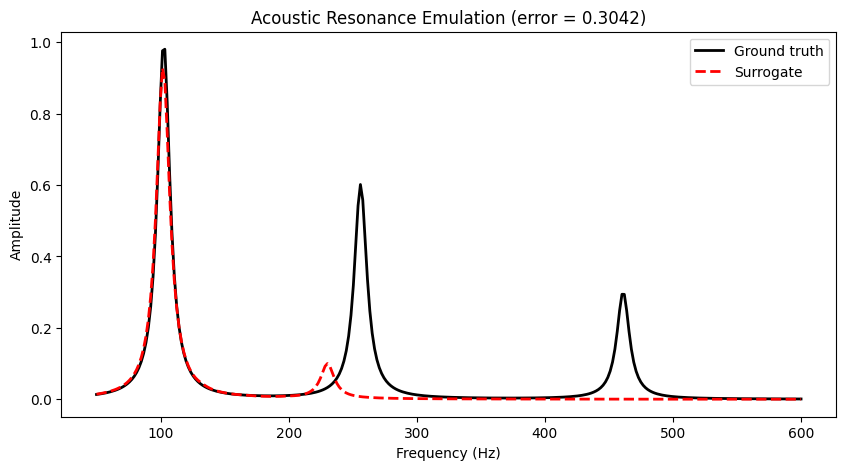

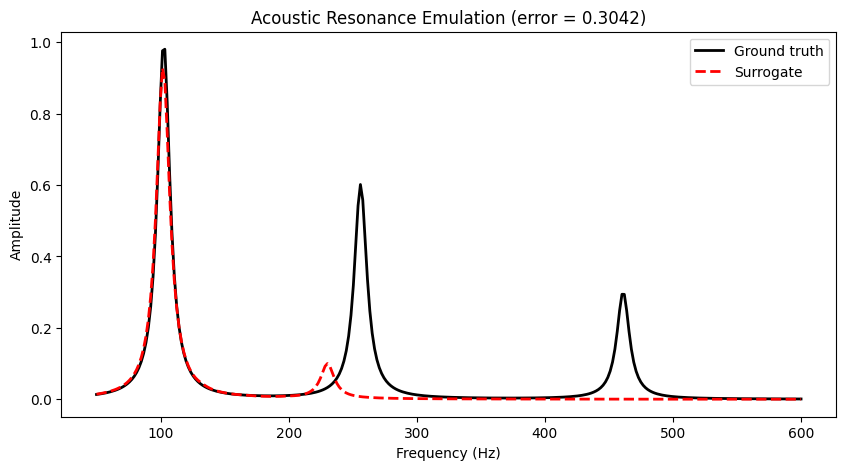

In [14]:
# Train surrogate
model = Surrogate('pmm', n_poles=11, retain=0.7)
# model = Surrogate('regression', n_components=4, width_mode='global', random_state=42)
model.fit(dataset)

# Predict at interpolation point
test_params = np.array([1.05, 1.2])
result = model.predict(test_params, freq)

# Compare to ground truth
truth = acoustic_spectrum(test_params, freq)
error = normalized_l2(result.spectrum, truth, freq)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq, truth, 'k-', lw=2, label='Ground truth')
ax.plot(freq, result.spectrum, 'r--', lw=2, label='Surrogate')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Acoustic Resonance Emulation (error = {error:.4f})')
ax.legend()
fig